In [1]:
## Scenic ##

import gc
import pickle

from pathlib import Path

import numpy as np

from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, to_tree

from sklearn.metrics import pairwise_distances

from statsmodels.stats.multitest import multipletests
from pygam import LinearGAM, s

import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import seaborn as sns

import anndata as ad
import scanpy as sc

import palantir
from pyscenic.rss import regulon_specificity_scores

np.random.seed(0)

%matplotlib inline

/home/deepak/pixi_envs/scenic/.pixi/envs/default/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/deepak/pixi_envs/scenic/.pixi/envs/default/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/deepak/pixi_envs/scenic/.pixi/envs/default/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/deepak/pixi_envs/scenic/.pixi/envs/default/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/deepak/pixi_envs/scenic/.pixi/envs/default/l

In [2]:
## Colors ##

red_cmap = LinearSegmentedColormap.from_list("red_smooth",["#fff5f0", "#fcbba1", "#fb6a4a", "#cb181d"])
red_cmap = LinearSegmentedColormap.from_list("red_smooth",["#fff5f0", "#fcbba1", "#fc9272", "#cb181d"])

# light_blue_cmap = LinearSegmentedColormap.from_list("light_blue_smooth", ['#d2e2e7', '#8fb7c5', '#1f6f8b'])
light_blue_cmap = LinearSegmentedColormap.from_list("light_blue_smooth", ['#d2e2e7', '#a5c5d0', '#1f6f8b'])

# blue_cmap = LinearSegmentedColormap.from_list("blue_smooth", ['#ece7f2', '#a6bddb', '#0570b0'])
blue_cmap = LinearSegmentedColormap.from_list("blue_smooth", ['#ece7f2', '#a6bddb', '#084594'])

green_cmap = LinearSegmentedColormap.from_list("green_smooth", ['#d6e7e5ff', '#7aa5a1ff', '#1c4442ff'])

rainbow_cmap = LinearSegmentedColormap.from_list("rainbow", [
    "#313695",
    "#4575b4",
    "#74add1",
    "#abd9e9",
    "#e0f3f8",
    "#ffffbf",
    "#fee090",
    "#fdae61",
    "#f46d43",
    "#d73027",
    "#a50026"])

In [3]:
## Import Organoid Data ##

scz_adata = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata_annotated_w_celltypist_scanvi.h5ad')

# remove stressed glia and doublets
scz_adata = scz_adata[(~scz_adata.obs['pred_dbl'])].copy()

# define pseudobulk column 
scz_adata.obs['Donor_Sample'] = scz_adata.obs['Donor'].astype('str') + '_' + scz_adata.obs['Sample Name'].astype('str')
scz_adata.obs['Donor_Sample_Celltype'] = scz_adata.obs['Donor_Sample'] + '_' + scz_adata.obs['CellType'].astype('str')
gc.collect()

4352

In [4]:
# ei branch probs
branch_probs_ei = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/trajectory_analyses/ei_branch_probs.csv', index_col=0)
branch_probs_di = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/trajectory_analyses/direct_indirect_branch_probs.csv', index_col=0)
branch_probs_di['Broad_Genotype'] = scz_adata.obs['Broad_Genotype']

## pickle load gene trends
in_path = "/mnt/sdb/scz_meta_analysis_processed/trajectory_analyses/ei_gene_trends.pkl"

with open(in_path, "rb") as f:
    gene_trends = pickle.load(f)

In [5]:
## Create Adata Objects ##

ei_adata = scz_adata[branch_probs_ei.index].copy()
di_adata = scz_adata[branch_probs_di.index].copy()

# add constants for grouping if necessary
ei_adata.obs['constant'] = 1
di_adata.obs['constant'] = 1

# merge on palantir series cols 
di_adata.obs = di_adata.obs.merge(branch_probs_di[['Direct', 'Indirect', 'palantir_pseudotime', 'Path',
                                                'palantir_entropy', 'assignment']], 
                                  left_index=True, right_index=True, how='left')

di_adata.obs['Path'] = di_adata.obs['Path'].astype('str')

ei_adata.obs = ei_adata.obs.merge(branch_probs_ei[['Excitatory', 'Inhibitory', 'palantir_pseudotime', 'Path',
                                                'palantir_entropy', 'assignment']], 
                                  left_index=True, right_index=True, how='left')

ei_adata.obs['Path'] = ei_adata.obs['Path'].astype('str')

# add broad genotype path
ei_adata.obs['Broad_Genotype_Path'] = ei_adata.obs['Broad_Genotype'].astype('str') + '_' + ei_adata.obs['Path'].astype('str')
di_adata.obs['Broad_Genotype_Path'] = di_adata.obs['Broad_Genotype'].astype('str') + '_' + di_adata.obs['Path'].astype('str')

## calculate neighbors 

sc.pp.neighbors(ei_adata, n_neighbors=15, use_rep='X_scVI')
sc.pp.neighbors(di_adata, n_neighbors=15, use_rep='X_scVI')

In [6]:
## Recalculate linear pseudotime for DI anndata ##

# 1. Define mask
mask = ((di_adata.obs['subclass_annotations'] == 'Radial Glia') & (di_adata.obs['Day'] == 22))

# 2. Get indices in full AnnData
subset_idx = np.where(mask)[0]

# 3. Pull scVI latent space
X = di_adata.obsm['X_scVI'][subset_idx]

# 4. Compute centroid in scVI space
centroid = X.mean(axis=0)

# 5. Find closest cell
dists = pairwise_distances(X, centroid.reshape(1, -1)).ravel()
closest_local_idx = np.argmin(dists)

# 6. Map back to original index
iroot = subset_idx[closest_local_idx]

# 7. Set root
di_adata.uns['iroot'] = int(iroot)

## Calculate linear pseudotime
sc.tl.diffmap(di_adata)
sc.tl.dpt(di_adata)

In [7]:
EXC_COLOR = "#d8b365"   # muted terracotta
INH_COLOR = "#5ab4ac"   # dusty cornflower

ei_adata.uns["Path_colors"] = [EXC_COLOR, INH_COLOR]

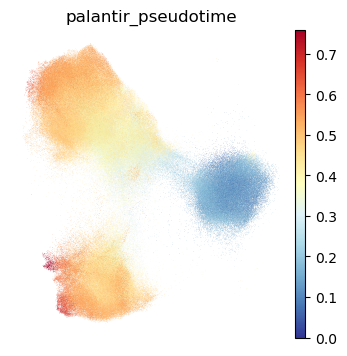

In [8]:
sc.pl.umap(ei_adata, color='palantir_pseudotime', frameon=False, cmap=rainbow_cmap, vmax='p99.9')

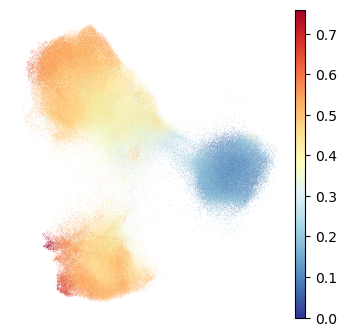

In [9]:
sc.pl.umap(ei_adata, color="palantir_pseudotime", show=False, legend_loc=None, title=None, 
           frameon=False, cmap=rainbow_cmap, vmax='p99.9')

ax = plt.gca()
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("")

plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Fig_Trajectory_excitatory_inhibitory_pseudotime_umap.png", 
            dpi=500, bbox_inches="tight")
plt.show()

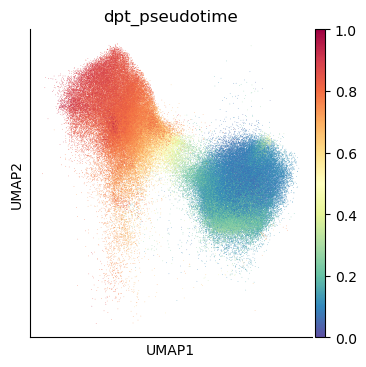

In [10]:
sc.pl.umap(di_adata, color='dpt_pseudotime')

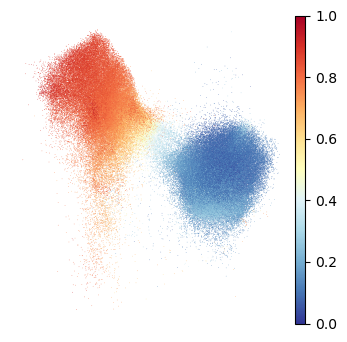

In [11]:
sc.pl.umap(di_adata, color="dpt_pseudotime", show=False, legend_loc=None, title=None, frameon=False, cmap=rainbow_cmap) #, vmax='p99')

ax = plt.gca()
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("")

plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Fig_Trajectory_direct_indirect_pseudotime_umap.png", 
            transparent=True,
            dpi=500, bbox_inches="tight")
plt.show()

/tmp/ipykernel_1393154/3888762501.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct = ei_adata.obs.groupby(["Broad_Genotype", "Path"]).size().unstack(fill_value=0)


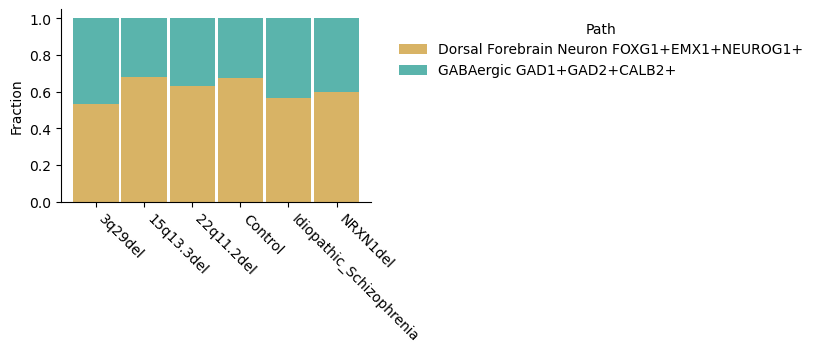

In [44]:
## Excitatory Inhibitory Stacked Barplots ##

ei_adata.obs["Path"] = branch_probs_ei["Path"]

# contingency table
ct = ei_adata.obs.groupby(["Broad_Genotype", "Path"]).size().unstack(fill_value=0)

# normalize per genotype
ct_norm = ct.div(ct.sum(axis=1), axis=0)

# --- explicit palette for your two paths ---
path_palette = {
    "Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+": "#d8b365",
    "GABAergic GAD1+GAD2+CALB2+": "#5ab4ac"
}

# ensure correct column order
ct_norm = ct_norm[list(path_palette.keys())]

fig, ax = plt.subplots(figsize=(4, 2.5))

ct_norm.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=[path_palette[c] for c in ct_norm.columns],
    width=0.95
)

# --- labels ---
ax.set_title("")
ax.set_ylabel("Fraction")
ax.set_xlabel("")

# rotate x tick labels
plt.setp(ax.get_xticklabels(), rotation=-45, ha="left")

# --- legend moved outside ---
ax.legend(
    title="Path",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False
)

sns.despine()

plt.savefig(
    "/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Fig_Trajectory_genotype_ei_stacked_barplot.svg",
    dpi=500,
    bbox_inches="tight"
)

plt.show()

/tmp/ipykernel_1393154/2022209082.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct = ei_adata.obs.groupby(["Donor", "Path"]).size().unstack(fill_value=0)


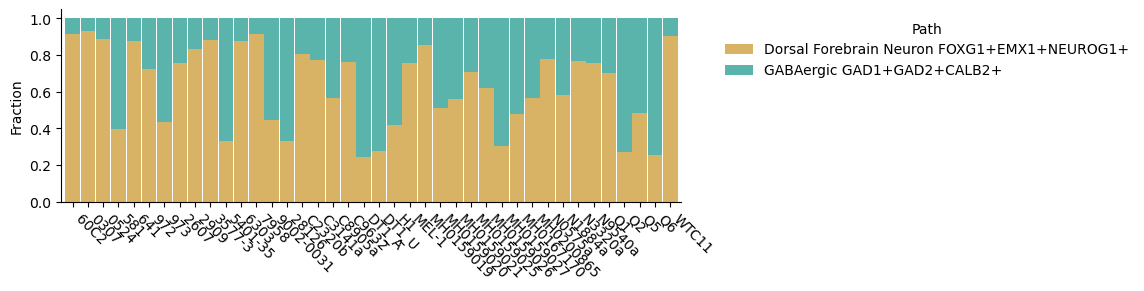

In [43]:
## Excitatory Inhibitory Stacked Barplots ##

ei_adata.obs["Path"] = branch_probs_ei["Path"]

# contingency table
ct = ei_adata.obs.groupby(["Donor", "Path"]).size().unstack(fill_value=0)

# normalize per manuscript
ct_norm = ct.div(ct.sum(axis=1), axis=0)

# --- explicit palette for your two paths ---
path_palette = {
    "Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+": "#d8b365",  # blue
    "GABAergic GAD1+GAD2+CALB2+": "#5ab4ac"  # orange
}

# ensure correct column order
ct_norm = ct_norm[list(path_palette.keys())]

fig, ax = plt.subplots(figsize=(8, 2.5))

ct_norm.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=[path_palette[c] for c in ct_norm.columns],
    width=0.95
)

# --- labels ---
ax.set_title("")
ax.set_ylabel("Fraction")
ax.set_xlabel("")

# rotate x tick labels
plt.setp(ax.get_xticklabels(), rotation=-45, ha="left")

# --- legend moved outside ---
ax.legend(
    title="Path",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False
)

sns.despine()
plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Fig_Trajectory_ei_donor_stacked_barplot.svg",
            dpi=500,  bbox_inches="tight")
plt.show()

/tmp/ipykernel_1393154/1347839786.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct = di_adata.obs.groupby(["Broad_Genotype", "Path"]).size().unstack(fill_value=0)


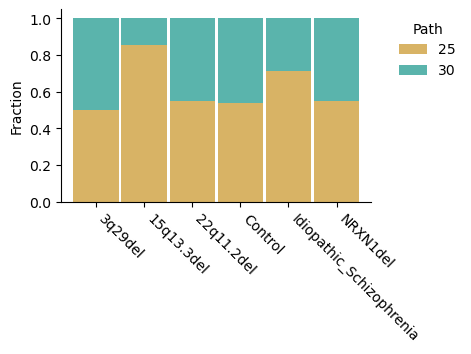

In [42]:
## Direct Indirect Stacked Barplots ##

# assign paths
di_adata.obs["Path"] = branch_probs_di["Path"]

# contingency table
ct = di_adata.obs.groupby(["Broad_Genotype", "Path"]).size().unstack(fill_value=0)

# normalize per manuscript
ct_norm = ct.div(ct.sum(axis=1), axis=0)

# --- explicit palette (consistent across figures) ---
path_palette = {
    25: "#d8b365",  # blue
    30: "#5ab4ac"  # orange
}

# ensure consistent column order
ct_norm = ct_norm[list(path_palette.keys())]

fig, ax = plt.subplots(figsize=(4, 2.5))

ct_norm.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=[path_palette[c] for c in ct_norm.columns],
    width=0.95)

# --- clean labels ---
ax.set_title("")
ax.set_xlabel("")
ax.set_ylabel("Fraction")

# rotate x tick labels
plt.setp(ax.get_xticklabels(), rotation=-45, ha="left")

# --- legend outside plot ---
ax.legend(title="Path", bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)

sns.despine()
plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Fig_Trajectory_di_stacked_barplot.svg", dpi=500, bbox_inches="tight")
plt.show()

/tmp/ipykernel_1393154/4273322485.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct = di_adata.obs.groupby(["Donor", "Path"]).size().unstack(fill_value=0)


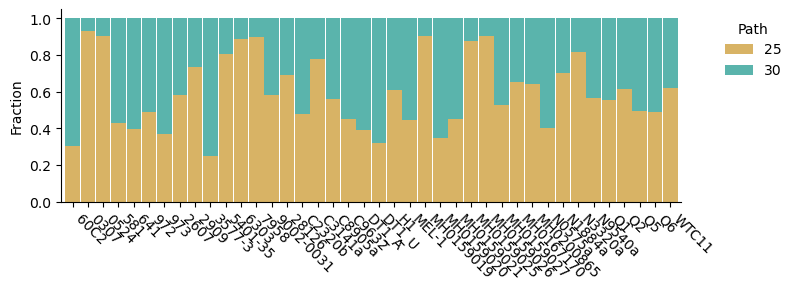

In [41]:
## Direct Indirect Stacked Barplots ##

# assign paths
di_adata.obs["Path"] = branch_probs_di["Path"]

# contingency table
ct = di_adata.obs.groupby(["Donor", "Path"]).size().unstack(fill_value=0)

# normalize per manuscript
ct_norm = ct.div(ct.sum(axis=1), axis=0)

# --- explicit palette (consistent across figures) ---
path_palette = {
    25: "#d8b365",  # blue
    30: "#5ab4ac"  # orange
}

# ensure consistent column order
ct_norm = ct_norm[list(path_palette.keys())]

fig, ax = plt.subplots(figsize=(8, 2.5))

ct_norm.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=[path_palette[c] for c in ct_norm.columns],
    width=0.95)

# --- clean labels ---
ax.set_title("")
ax.set_xlabel("")
ax.set_ylabel("Fraction")

# rotate x tick labels
plt.setp(ax.get_xticklabels(), rotation=-45, ha="left")

# --- legend outside plot ---
ax.legend(title="Path", bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)

sns.despine()
plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Fig_Trajectory_di_donor_stacked_barplot.svg", dpi=500, bbox_inches="tight")
plt.show()

<Axes: xlabel='Day_bin', ylabel='palantir_pseudotime'>

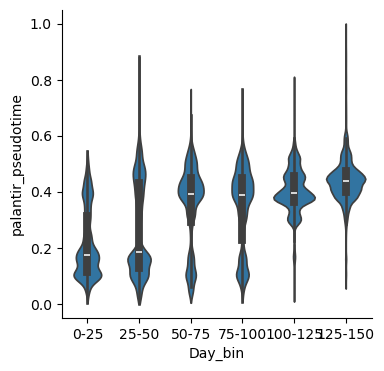

In [16]:
# create bins every 25
bins = np.arange(0, 175, 25)  # 0,25,50,...,350

labels = [f"{i}-{i+25}" for i in bins[:-1]]

ei_adata.obs["Day_bin"] = pd.cut(ei_adata.obs["Day"],  bins=bins,  labels=labels,  include_lowest=True)

# plot
sns.violinplot(data=ei_adata.obs, x="Day_bin", y="palantir_pseudotime", legend=False, cut=0)

/tmp/ipykernel_1393154/1851396217.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha='right')  # Align x-axis labels to the right


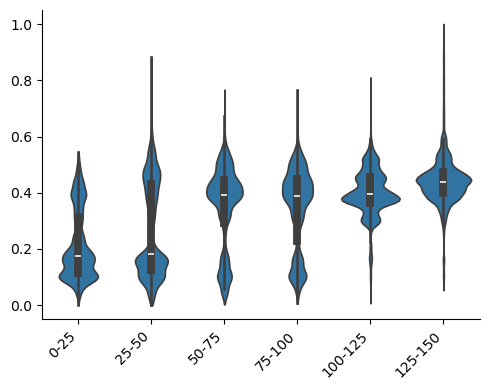

In [17]:
bins = np.arange(0, 175, 25)
labels = [f"{i}-{i+25}" for i in bins[:-1]]
ei_adata.obs["Day_bin"] = pd.cut(ei_adata.obs["Day"], bins=bins, labels=labels, include_lowest=True)

fig, ax = plt.subplots(figsize=(5,4))

sns.violinplot(data=ei_adata.obs, x="Day_bin", y="palantir_pseudotime", cut=0, ax=ax)

ax.set(xlabel="", ylabel="", title="")
ax.tick_params(axis="x", rotation=45)
ax.set_xticklabels(ax.get_xticklabels(), ha='right')  # Align x-axis labels to the right
sns.despine()

plt.tight_layout()
plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Fig_Trajectory_ei_violin_pseudotime_by_day.svg",
            dpi=300, bbox_inches="tight")
plt.show()

<Axes: xlabel='Day_bin', ylabel='palantir_pseudotime'>

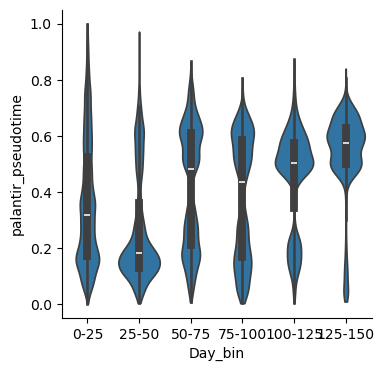

In [18]:
# create bins every 25
bins = np.arange(0, 175, 25)  # 0,25,50,...,350

labels = [f"{i}-{i+25}" for i in bins[:-1]]

di_adata.obs["Day_bin"] = pd.cut(
    di_adata.obs["Day"],
    bins=bins,
    labels=labels,
    include_lowest=True)

# plot
sns.violinplot(data=di_adata.obs, x="Day_bin", y="palantir_pseudotime", legend=False, cut=0)

/tmp/ipykernel_1393154/3470788485.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha='right')  # Align x-axis labels to the right


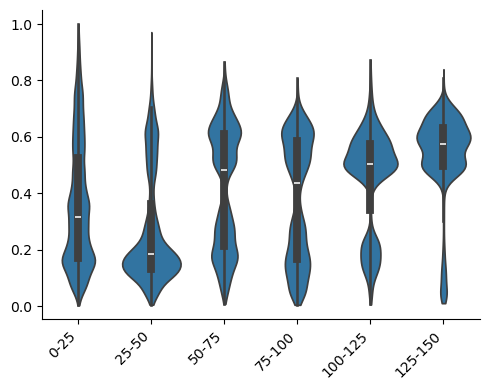

In [19]:
bins = np.arange(0, 175, 25)
labels = [f"{i}-{i+25}" for i in bins[:-1]]
di_adata.obs["Day_bin"] = pd.cut(di_adata.obs["Day"], bins=bins, labels=labels, include_lowest=True)

fig, ax = plt.subplots(figsize=(5,4))

sns.violinplot(data=di_adata.obs, x="Day_bin", y="palantir_pseudotime", cut=0, ax=ax)

ax.set(xlabel="", ylabel="", title="")
ax.tick_params(axis="x", rotation=45, labelsize=10)
ax.set_xticklabels(ax.get_xticklabels(), ha='right')  # Align x-axis labels to the right
sns.despine()

plt.tight_layout()
plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Fig_Trajectory_di_violin_pseudotime_by_day.svg",
            dpi=300, bbox_inches="tight")
plt.show()